# Homework 2

- I recommend that you start with "hw2.tex" first.
- When you turn in the assignment, do not clear the output.
- Make sure that your python notebook can run end-to-end with no mistake, in case the figures need to be reproduced.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1 Conditional Probability

## [2] point(s) --- part b:

- Complete this after you finish "1 Conditional Probability --- part a" from "hw2.tex".

- Generate `y = wx + b + eps` where `eps` is constructed by the pseudo code in "1 Conditional Probability --- part a".

- Your task is to generate `eps` by changing the line with the comment "# YOUR ANSWER HERE".

- Leave all other lines as is.

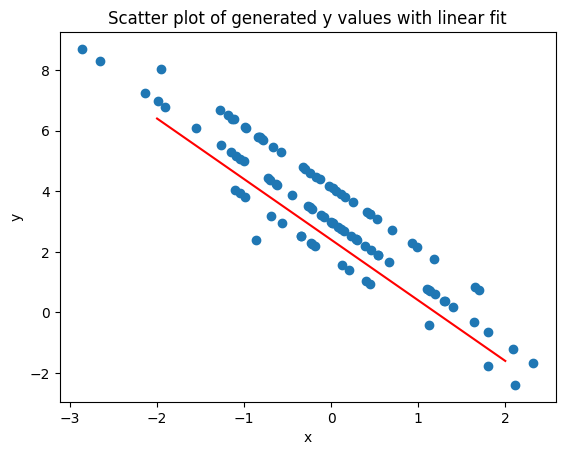

In [22]:
np.random.seed(1729)
N = 100
n = 3
w_star = -2.0
b_star = 2.4
x = np.random.randn(N)

# YOUR ANSWER HERE
occurances = np.where(np.random.randn(N,n) < 0.5 , 1, -1) #

# Generate eps using the function
eps = occurances.sum(axis=1) / np.sqrt(n)

# eps = None # YOUR ANSWER HERE
y = w_star*x + b_star + eps

x_grid = np.linspace(-2, 2)
plt.plot(x_grid, w_star * x_grid + b_star, color='r')
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of generated y values with linear fit')
plt.show()

## [2] point(s) --- part c:

In the previous parts, you see should scatter points following 4 distinct lines.

- Calculate how many scatter points belong to each of the lines.
- Store the results into `n1,n2,n3,n4` such that `n1 >= n2 >= n3 >= n4`

In [9]:
# YOUR ANSWER HERE (use as many lines as needed)


y1 = w_star * x + b_star + np.sqrt(3)
y2 = w_star * x + b_star + 1 / np.sqrt(3)
y3 = w_star * x + b_star - 1 / np.sqrt(3)
y4 = w_star * x + b_star - np.sqrt(3)


n1 = np.sum(np.isclose(y, y1))
n2 = np.sum(np.isclose(y, y2))
n3 = np.sum(np.isclose(y, y3))
n4 = np.sum(np.isclose(y, y4))


n_values = [n1, n2, n3, n4]
n_values.sort(reverse=True)
n1, n2, n3, n4 = n_values

# Print the results
total = n1 + n2 + n3 + n4  # do not change this line
print(n1 / total, n2 / total, n3 / total, n4 / total)  # do not change this line


0.41 0.31 0.14 0.14


Here is the recreated plot with the y1, y2, y3, y4 lines and their data points for better illustration-


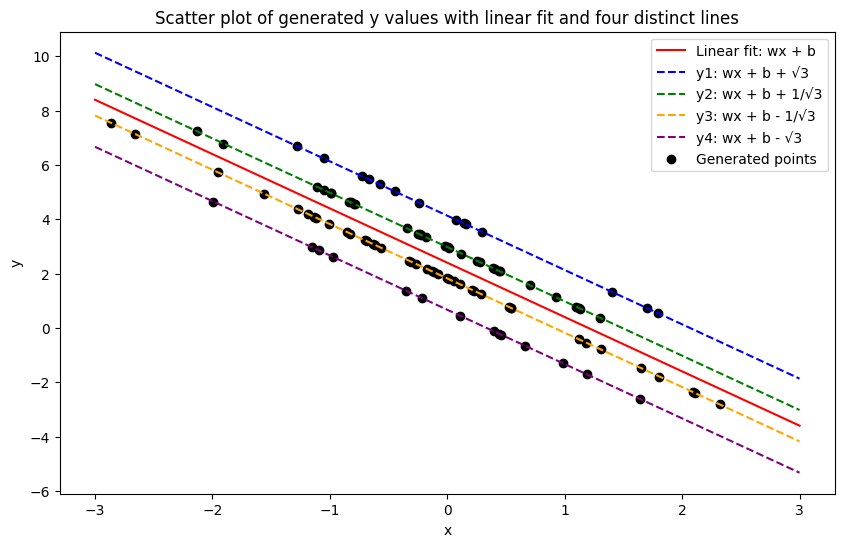

In [10]:
x_grid = np.linspace(-3, 3, 100)

plt.figure(figsize=(10, 6))


plt.plot(x_grid, w_star * x_grid + b_star, color='red', label='Linear fit: wx + b')


plt.plot(x_grid, w_star * x_grid + b_star + np.sqrt(3), label='y1: wx + b + √3', color='blue', linestyle='--')
plt.plot(x_grid, w_star * x_grid + b_star + 1 / np.sqrt(3), label='y2: wx + b + 1/√3', color='green', linestyle='--')
plt.plot(x_grid, w_star * x_grid + b_star - 1 / np.sqrt(3), label='y3: wx + b - 1/√3', color='orange', linestyle='--')
plt.plot(x_grid, w_star * x_grid + b_star - np.sqrt(3), label='y4: wx + b - √3', color='purple', linestyle='--')


plt.scatter(x, y, color='black', label='Generated points')


plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of generated y values with linear fit and four distinct lines')
plt.legend()
plt.show()


# 2 The Gaussian distribution

## [1] point(s) --- part c:

- Implement the data generative process from part a.

- Compute the number of elements of `y` that is between 1 ± 0.1. Store that into n1

- Compute the number of elements of `y` that is between 0 ± 0.1. Store that into n2

In [ ]:
import numpy as np

N = 10000

np.random.seed(1729)

w = np.array([0,1])
b = 3
x = np.vstack([[1,-2] for _ in range(N)])

eps = np.random.normal(0, 1/np.sqrt(2), N) # YOUR ANSWER HERE

y = x@w + b + eps

# YOUR ANSWER HERE
n1 = np.sum ( (y >= 1 - 0.1)       & (y <= 1 + 0.1) )#
n2 = np.sum (( y >= - (1/2) - 0.1) & (y <= - (1/2) + 0.1))

print (n1/n2)# YOUR ANSWER HERE (only modify this line)


8.325757575757576


# 3 Gradient descent for nonlinear regression

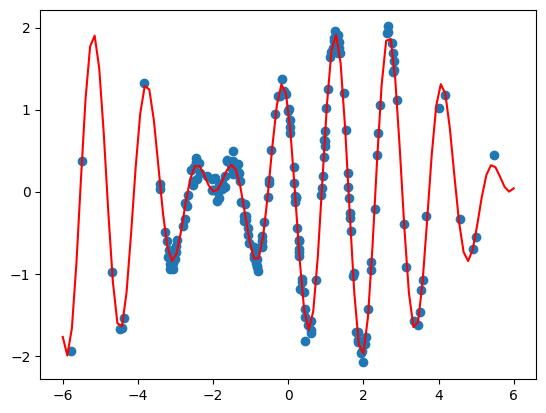

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

N = 200

np.random.seed(1729)

w1_star = -4.0
w2_star = 4.8

x = np.concatenate([1.5*(np.random.randn(N//2)-1), 1.5*(np.random.randn(N//2)+1)])
eps = (1/10)*np.random.randn(N)

y = np.sin(w1_star*x) + np.cos(w2_star*x)+eps

plt.scatter(x,y)

x_grid = np.linspace(-6,6,100)
plt.plot(x_grid, np.sin(w1_star*x_grid) + np.cos(w2_star*x_grid), color ='r')

## [1] points --- part b

In [2]:
def J(w1, w2):
    predictions = np.sin(w1*x) + np.cos(w2*x) # YOUR CODE HERE
    mse = (1/N) * np.sum((y - predictions) ** 2)
    return mse

def dJdw1(w1, w2):
    N = len(y)
    grad_w1 = (-2/N) * np.sum((y - (np.sin(w1*x) + np.cos(w2*x))) * x * np.cos(w1*x)) # YOUR CODE HERE
    return grad_w1

def dJdw2(w1, w2):
    N = len(y)
    grad_w2 = (2/N) * np.sum((y - (np.sin(w1*x) + np.cos(w2*x))) * x * np.sin(w2*x)) # YOUR CODE HERE
    return grad_w2

## [4] points --- part c

For this part, only your response in `hw2.tex` will be graded. You can use as many code blocks below as you like.

In [3]:
## initialization A
w1 = -2.5
b1 = 3.56

## initialization B
w2 = -2.5
b2 = 3.57

In [4]:
# plot_J_surface() # you might find plotting the J function helpful

def plot_J_surface(alpha=1.0):
    w1_values = np.linspace(-6, 1, 100)
    w2_values = np.linspace(-1, 6, 100)
    W, B = np.meshgrid(w1_values, w2_values)

    Z = np.array([[J(w1,w2) for w1 in w1_values] for w2 in w2_values])

    fig = go.Figure(data=[go.Surface(z=Z, x=w1_values, y=w2_values,opacity=alpha)])

    fig.update_layout(title='J(w1, w2) surface plot',
                      scene=dict(xaxis_title='w1',
                                 yaxis_title='w2',
                                 zaxis_title='MSE') ,
                      width=800, height=600)

    return fig


def plot_line_segment(fig, w1, b1, w2, b2, color='blue'):
    mse1 = J(w1, b1)
    mse2 = J(w2, b2)

    fig.add_trace(go.Scatter3d(x=[w1, w2], y=[b1, b2], z=[mse1, mse2],
                               mode='lines',
                               line=dict(color=color, width=2),
                               name=f'Line Segment ({w1}, {b1}) -> ({w2}, {b2})'))


def plot_point(fig, w, b, color='red'):
    mse = J(w, b)
    fig.add_trace(go.Scatter3d(x=[w], y=[b], z=[mse],
                               mode='markers',
                               marker=dict(size=5, color=color),
                               name=f'Point (w={w}, b={b})'))
plot_J_surface()

In [5]:
def gradient_descent(w, b, learning_rate=0.25, iterations=100):
    for i in range(iterations):
        w -= learning_rate * dJdw1(w, b)
        b -=  learning_rate * dJdw2(w, b)
        # Print MSE and weights after every 5 iterations
        if i % 5 == 0:
            MSE = J(w, b)
            print(f"Iteration {i}: MSE = {MSE:.4f}, w = {w:.4f}, b = {b:.4f}")

    final_MSE = J(w, b)
    print(f"Final MSE = {final_MSE:.4f}")

    return w, b

np.random.seed(0)


print("Running Gradient Descent with Initialization A (w1 = -2.5, b1 = 3.56)")
w_final_A, b_final_A = gradient_descent(w1, b1)
print(f"Final weights (A): w = {w_final_A:.4f}, b = {b_final_A:.4f}\n")

print("Running Gradient Descent with Initialization B (w2 = -2.5, b2 = 3.57)")
w_final_B, b_final_B = gradient_descent(w2, b2)
print(f"Final weights (B): w = {w_final_B:.4f}, b = {b_final_B:.4f}")

Running Gradient Descent with Initialization A (w1 = -2.5, b1 = 3.56)
Iteration 0: MSE = 2.3072, w = -2.4960, b = 3.6051
Iteration 5: MSE = 1.4088, w = -2.5688, b = 4.4586
Iteration 10: MSE = 1.1419, w = -2.5314, b = 4.7928
Iteration 15: MSE = 1.0431, w = -2.2176, b = 4.7821
Iteration 20: MSE = 1.0073, w = -2.0244, b = 4.7761
Iteration 25: MSE = 1.0072, w = -2.0101, b = 4.7758
Iteration 30: MSE = 1.0072, w = -2.0088, b = 4.7758
Iteration 35: MSE = 1.0072, w = -2.0087, b = 4.7758
Iteration 40: MSE = 1.0072, w = -2.0087, b = 4.7758
Iteration 45: MSE = 1.0072, w = -2.0087, b = 4.7758
Iteration 50: MSE = 1.0072, w = -2.0087, b = 4.7758
Iteration 55: MSE = 1.0072, w = -2.0087, b = 4.7758
Iteration 60: MSE = 1.0072, w = -2.0087, b = 4.7758
Iteration 65: MSE = 1.0072, w = -2.0087, b = 4.7758
Iteration 70: MSE = 1.0072, w = -2.0087, b = 4.7758
Iteration 75: MSE = 1.0072, w = -2.0087, b = 4.7758
Iteration 80: MSE = 1.0072, w = -2.0087, b = 4.7758
Iteration 85: MSE = 1.0072, w = -2.0087, b = 4.7

## [10 bonus] points --- part d